In [1]:
from optunaz.three_step_opt_build_merge import (
    optimize,
    buildconfig_best,
    build_best,
    build_merged,
)
from optunaz.config import ModelMode, OptimizationDirection
from optunaz.config.optconfig import (
    OptimizationConfig,
    RandomForestClassifier,
    SVC,
    LogisticRegression,
    KNeighborsClassifier,
    AdaBoostClassifier,
    PRFClassifier,
)
from optunaz.datareader import Dataset
from optunaz.descriptors import (ECFP,
                                 MACCS_keys,
                                 ECFP_counts,
                                 PathFP,
                                 PhyschemDescriptors,
                                 CompositeDescriptor,
                                 UnscaledPhyschemDescriptors,
                                 JazzyDescriptors,
                                 PhyschemDescriptors,
                                 Avalon)

from optunaz.utils.preprocessing.splitter import Stratified
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sklearn
from sklearn.metrics import *
sns.set_theme(style="white", palette='bright')

# TM-60

[I 2025-06-26 15:00:13,917] A new study created in memory with name: tm60
[I 2025-06-26 15:00:13,964] A new study created in memory with name: study_name_0
[I 2025-06-26 15:00:18,973] Trial 0 finished with value: 0.5112300435413644 and parameters: {'algorithm_name': 'SVC', 'SVC_algorithm_hash': 'c065533ac9699d8b5e1b9d31bde5b5ed', 'gamma__c065533ac9699d8b5e1b9d31bde5b5ed': 0.0008632008168602544, 'C__c065533ac9699d8b5e1b9d31bde5b5ed': 7.446192235373419e-09, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D

Duplicated trial: {'algorithm_name': 'KNeighborsClassifier', 'KNeighborsClassifier_algorithm_hash': 'e51ca55089f389fc37a736adb2aa0e42', 'metric__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsMetric.MINKOWSKI: 'minkowski'>, 'n_neighbors__e51ca55089f389fc37a736adb2aa0e42': 10, 'weights__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsWeights.UNIFORM: 'uniform'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "MACCS_keys", "parameters": {}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "Be

[I 2025-06-26 15:01:04,340] Trial 36 finished with value: 0.6691763425253991 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 218, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "BertzCT", "Chi0", "Chi0n",

Duplicated trial: {'algorithm_name': 'LogisticRegression', 'LogisticRegression_algorithm_hash': '8908f22fafa8a855aeb58e3dc9f9ce8e', 'solver__8908f22fafa8a855aeb58e3dc9f9ce8e': 'newton-cg', 'C__8908f22fafa8a855aeb58e3dc9f9ce8e': 1.0, 'descriptor': '{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}'}, return [0.7194484760522497]


[I 2025-06-26 15:01:25,392] Trial 52 finished with value: 0.7196298984034833 and parameters: {'algorithm_name': 'LogisticRegression', 'LogisticRegression_algorithm_hash': '8908f22fafa8a855aeb58e3dc9f9ce8e', 'solver__8908f22fafa8a855aeb58e3dc9f9ce8e': 'lbfgs', 'C__8908f22fafa8a855aeb58e3dc9f9ce8e': 1.0, 'descriptor': '{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}'}. Best is trial 17 with value: 0.7386066763425254.
[I 2025-06-26 15:01:25,905] Trial 53 finished with value: 0.6906023222060959 and parameters: {'algorithm_name': 'LogisticRegression', 'LogisticRegression_algorithm_hash': '8908f22fafa8a855aeb58e3dc9f9ce8e', 'solver__8908f22fafa8a855aeb58e3dc9f9ce8e': 'lbfgs', 'C__8908f22fafa8a855aeb58e3dc9f9ce8e': 1.0, 'descriptor': '{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}'}. Best is trial 17 with value: 0.7386066763425254.
[I 2025-06-26 15:01:25,928] Trial 54 pruned. Duplicate parameter set


...

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 4, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 107, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}'}, return [0.7537735849056604]


[I 2025-06-26 15:04:20,508] Trial 193 finished with value: 0.7501632801161103 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 3, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 89, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}'}. Best is trial 138 with value: 0.7544992743105949.
[I 2025-06-26 15:04:21,172] Trial 194 finished with value: 0.7505079825834542 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 4, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 53, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name":

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 4, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 104, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}'}, return [0.7533381712626996]


[I 2025-06-26 15:04:23,370] Trial 198 finished with value: 0.7319484760522498 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 2, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 97, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}'}. Best is trial 138 with value: 0.7544992743105949.
[I 2025-06-26 15:04:24,410] Trial 199 finished with value: 0.6726415094339623 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 6, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 116, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"param

QSARtunaModel(predictor=RandomForestClassifier(class_weight='balanced', max_depth=4, max_features=1.0,
                       n_estimators=151, n_jobs=-1, random_state=42), descriptor=ECFP_counts(name='ECFP_counts', parameters=ECFP_counts.Parameters(radius=3, useFeatures=True, nBits=2048)), mode=<ModelMode.CLASSIFICATION: 'classification'>, transform=None, aux_transform=None, metadata={'name': '', 'buildconfig': {'data': {'training_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\RS_datasets\\tobramycin_train_NM-RS42.csv', 'input_column': 'Structure', 'response_column': 'Class', 'response_type': 'classification', 'deduplication_strategy': {'name': 'KeepMedian'}, 'split_strategy': {'name': 'NoSplitting'}, 'test_dataset_file': 'M:\\ML_scripts\\MODEL DATA\\RS_datasets\\tobramycin_test_NM-RS42.csv', 'save_intermediate_files': False, 'log_transform': False, 'log_transform_base': None, 'log_transform_negative': None, 'log_transform_unit_conversion': None, 'probabilistic_threshold_representation':

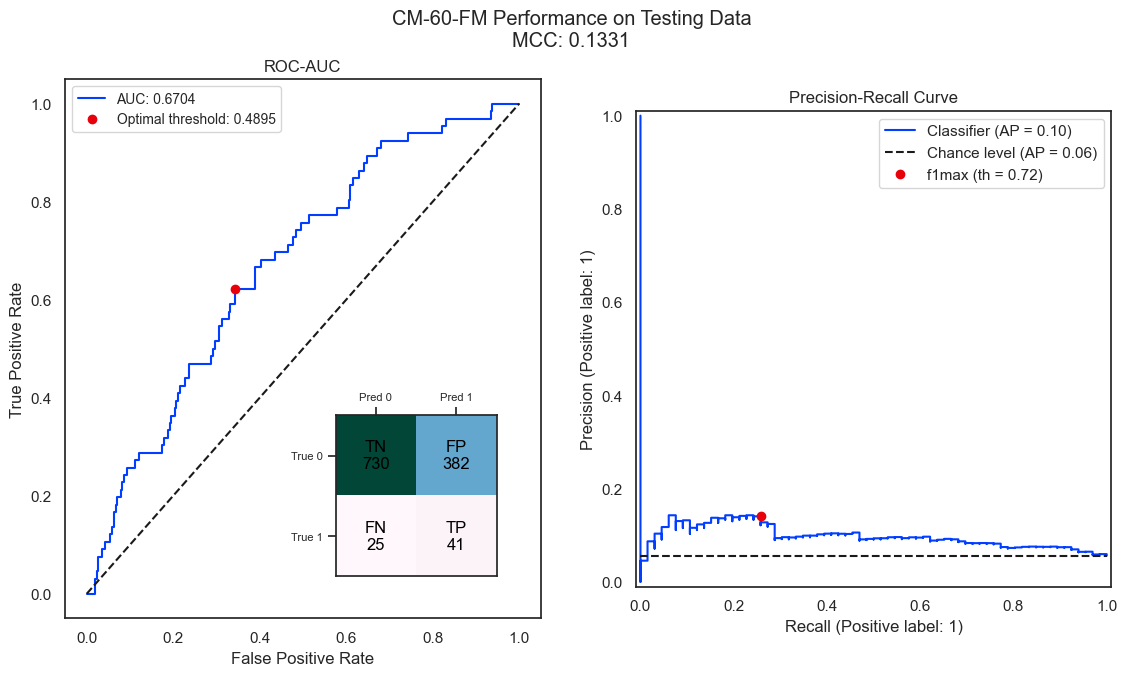

In [3]:
config = OptimizationConfig(
        data=Dataset(
            input_column='Structure',
            response_column='Class',
            training_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_train_NM-RS42.csv',
            test_dataset_file=r'M:\ML_scripts\MODEL DATA\RS_datasets\tobramycin_test_NM-RS42.csv',
        ),
        descriptors=[
            ECFP.new(),
            ECFP_counts.new(),
            MACCS_keys.new(),
            PhyschemDescriptors.new(),
            UnscaledPhyschemDescriptors.new(),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP_counts.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    MACCS_keys.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            )
        ],
        algorithms=[
            RandomForestClassifier.new(),
            SVC.new(),
            LogisticRegression.new(),
            KNeighborsClassifier.new(),
        ],
        settings=OptimizationConfig.Settings(
            mode=ModelMode.CLASSIFICATION,
            cross_validation=10,
            cv_split_strategy=Stratified(),
            n_trials=200,
            n_startup_trials=50,
            direction=OptimizationDirection.MAXIMIZATION,
            random_seed=42,
            n_jobs=-1,
        ),
    )

study = optimize(config, study_name='tm60')

build_best(buildconfig_best(study), r"./tm60_cv.pkl")

# build_merged(buildconfig_best(study), r"./cm60_full_merged.pkl")

with open(r"./tm60_cv.pkl", "rb") as m:
    model = pickle.load(m)

print(model)

fig, axs = plt.subplots(1,2, figsize=(13.5, 7))        
x = np.linspace(0,1)


test_data = pd.read_csv(config.data.test_dataset_file)  
test_smiles = test_data[config.data.input_column]       
y_true = test_data[config.data.response_column]    

y_pred = model.predict_from_smiles(test_smiles)         


plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) 
auc = np.trapz(tpr, fpr)                                    
plt.plot(fpr, tpr)                                          
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"CM-60-FM Performance on Testing Data\nMCC: {mcc:.4}")     
                        
cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
name = "CM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()

# CM-60

[I 2025-06-26 16:12:27,090] A new study created in memory with name: cm60
[I 2025-06-26 16:12:27,141] A new study created in memory with name: study_name_0
[I 2025-06-26 16:12:45,697] Trial 0 finished with value: 0.5081239742456761 and parameters: {'algorithm_name': 'SVC', 'SVC_algorithm_hash': 'c065533ac9699d8b5e1b9d31bde5b5ed', 'gamma__c065533ac9699d8b5e1b9d31bde5b5ed': 0.0008632008168602544, 'C__c065533ac9699d8b5e1b9d31bde5b5ed': 7.446192235373419e-09, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D

Duplicated trial: {'algorithm_name': 'KNeighborsClassifier', 'KNeighborsClassifier_algorithm_hash': 'e51ca55089f389fc37a736adb2aa0e42', 'metric__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsMetric.MINKOWSKI: 'minkowski'>, 'n_neighbors__e51ca55089f389fc37a736adb2aa0e42': 10, 'weights__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsWeights.UNIFORM: 'uniform'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "MACCS_keys", "parameters": {}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "Be

[I 2025-06-26 16:14:54,192] Trial 36 finished with value: 0.7575937381643731 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 218, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "BertzCT", "Chi0", "Chi0n",

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 12, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 249, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-06-26 16:17:41,236] Trial 72 finished with value: 0.7748390354753188 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 13, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 233, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO",

...

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 13, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 236, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-06-26 16:27:05,328] Trial 192 finished with value: 0.7737406893069056 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 14, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 247, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO"

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 13, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 224, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc"

[I 2025-06-26 16:27:12,706] Trial 195 finished with value: 0.7741699280393889 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 11, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 241, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO"

QSARtunaModel(predictor=RandomForestClassifier(class_weight='balanced', max_depth=13, max_features=1.0,
                       n_estimators=225, n_jobs=-1, random_state=42), descriptor=CompositeDescriptor(parameters=CompositeDescriptor.Parameters(descriptors=[ECFP(name='ECFP', parameters=ECFP.Parameters(radius=3, nBits=2048, returnRdkit=False)), UnscaledPhyschemDescriptors(name='UnscaledPhyschemDescriptors', parameters=UnscaledPhyschemDescriptors.Parameters(rdkit_names=['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi

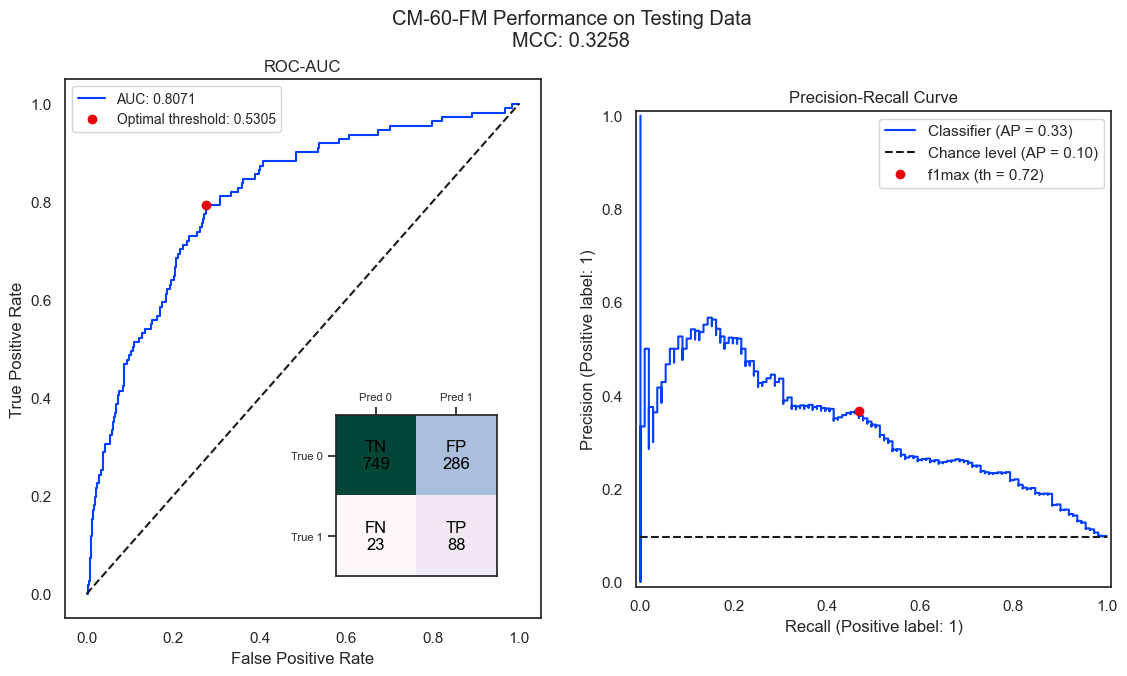

In [ ]:
config2 = OptimizationConfig(
        data=Dataset(
            input_column='Structure',
            response_column='Class',
            training_dataset_file=r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_training_set.csv',
            test_dataset_file=r'M:\ML_scripts\MODEL DATA\colistin models_data\colistin_testing_set.csv',
        ),
        descriptors=[
            ECFP.new(),
            ECFP_counts.new(),
            MACCS_keys.new(),
            PhyschemDescriptors.new(),
            UnscaledPhyschemDescriptors.new(),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP_counts.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    MACCS_keys.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            ),
            CompositeDescriptor.new(
                descriptors=[
                    ECFP.new(),
                    UnscaledPhyschemDescriptors.new(),
                ]
            )
        ],
        algorithms=[
            RandomForestClassifier.new(),
            SVC.new(),
            LogisticRegression.new(),
            KNeighborsClassifier.new(),
        ],
        settings=OptimizationConfig.Settings(
            mode=ModelMode.CLASSIFICATION,
            cross_validation=10,
            cv_split_strategy=Stratified(),
            n_trials=200,
            n_startup_trials=50,
            direction=OptimizationDirection.MAXIMIZATION,
            random_seed=42,
            n_jobs=-1
        ),
    )

study2 = optimize(config2, study_name='cm60')

build_best(buildconfig_best(study2), r"./cm60_cv.pkl")

# build_merged(buildconfig_best(study2), r"./cm60_full_merged.pkl")

with open(r"./cm60_cv.pkl", "rb") as m:
    model2 = pickle.load(m)

print(model2)

fig, axs = plt.subplots(1,2, figsize=(13.5, 7))        

x = np.linspace(0,1)

test_data = pd.read_csv(config2.data.test_dataset_file)  
test_smiles = test_data[config2.data.input_column]       
y_true = test_data[config2.data.response_column]    

y_pred = model2.predict_from_smiles(test_smiles)         

plt.subplot(121)

# Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred) 
auc = np.trapz(tpr, fpr)                                    
plt.plot(fpr, tpr)                                          
axs[0].set_title('ROC-AUC')

# Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

# Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"CM-60 Performance on Testing Data\nMCC: {mcc:.4}")     
                        
cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
name = "CM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()

# TM-65

[I 2025-06-27 09:59:32,257] A new study created in memory with name: tm65
[I 2025-06-27 09:59:32,303] A new study created in memory with name: study_name_0
[I 2025-06-27 09:59:34,484] Trial 0 finished with value: 0.5040408163265305 and parameters: {'algorithm_name': 'SVC', 'SVC_algorithm_hash': 'c065533ac9699d8b5e1b9d31bde5b5ed', 'gamma__c065533ac9699d8b5e1b9d31bde5b5ed': 0.0008632008168602544, 'C__c065533ac9699d8b5e1b9d31bde5b5ed': 7.446192235373419e-09, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D

Duplicated trial: {'algorithm_name': 'KNeighborsClassifier', 'KNeighborsClassifier_algorithm_hash': 'e51ca55089f389fc37a736adb2aa0e42', 'metric__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsMetric.MINKOWSKI: 'minkowski'>, 'n_neighbors__e51ca55089f389fc37a736adb2aa0e42': 10, 'weights__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsWeights.UNIFORM: 'uniform'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "MACCS_keys", "parameters": {}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "Be

[I 2025-06-27 09:59:58,822] Trial 36 finished with value: 0.6714285714285715 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 218, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "BertzCT", "Chi0", "Chi0n",

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 26, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 249, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "A

[I 2025-06-27 10:00:40,373] Trial 64 finished with value: 0.697265306122449 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 25, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 241, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CH

...

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 225, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "A

[I 2025-06-27 10:04:41,081] Trial 192 finished with value: 0.6982448979591837 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 31, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 229, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 32, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 228, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "A

[I 2025-06-27 10:04:48,496] Trial 196 finished with value: 0.6968979591836735 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 31, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 235, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 29, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 224, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "A

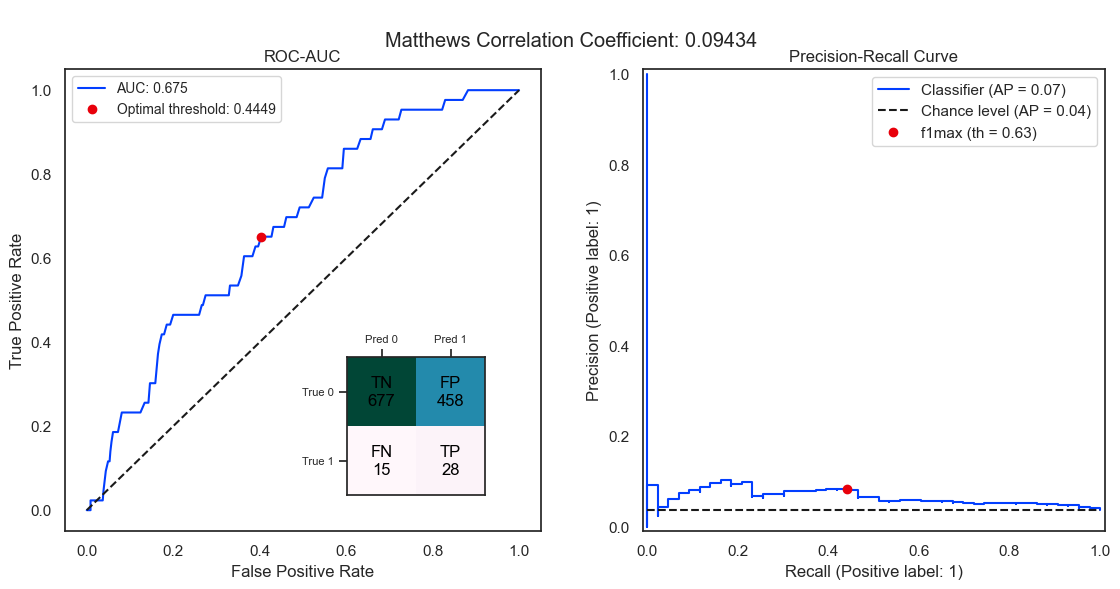

In [77]:
config3 = OptimizationConfig(        
    
    data = Dataset(
        input_column = 'Structure',
        response_column = 'Class',
        training_dataset_file=r'M:\ML_scripts\65_assay\tobramycin_train.csv',
        test_dataset_file=r'M:\ML_scripts\65_assay\tobramycin_test.csv',
    ),
    descriptors=[
        ECFP.new(),
        ECFP_counts.new(),
        MACCS_keys.new(),
        PhyschemDescriptors.new(),
        UnscaledPhyschemDescriptors.new(),
        CompositeDescriptor.new(
            descriptors=[
                ECFP_counts.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                MACCS_keys.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                ECFP.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        )
    ],
    algorithms=[
        RandomForestClassifier.new(),
        SVC.new(),
        LogisticRegression.new(),
        KNeighborsClassifier.new(),
    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        cv_split_strategy=Stratified(),
        n_trials=200,
        n_startup_trials=50,
        direction=OptimizationDirection.MAXIMIZATION,
        random_seed=42,
        n_jobs=-1
    ),
)

study3 = optimize(config3, study_name='tm65')                                                                                                   

build_best(buildconfig_best(study3), "./tm65_cv.pkl")                                 

with open("./tm65_cv.pkl", "rb") as f:                                                
    model3 = pickle.load(f)


fig, axs = plt.subplots(1,2, figsize=(13.5, 6))         
x = np.linspace(0,1)

test_data = pd.read_csv(config3.data.test_dataset_file)  
test_smiles = test_data[config3.data.input_column]       
y_true = test_data[config3.data.response_column]   

y_pred = model3.predict_from_smiles(test_smiles)       

plt.subplot(121)
## Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred)
auc = np.trapz(tpr, fpr)    

plt.plot(fpr, tpr)                                           
axs[0].set_title('ROC-AUC')

## Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]
x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]


plt.plot(x_coord, y_coord,'ro');
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

## Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"\nMatthews Correlation Coefficient: {mcc:.4}") 
                          

cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
name = "CM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()

# CM-65

[I 2025-06-27 10:06:05,068] A new study created in memory with name: cm65
[I 2025-06-27 10:06:05,072] A new study created in memory with name: study_name_0
[I 2025-06-27 10:06:17,248] Trial 0 finished with value: 0.5326638282117734 and parameters: {'algorithm_name': 'SVC', 'SVC_algorithm_hash': 'c065533ac9699d8b5e1b9d31bde5b5ed', 'gamma__c065533ac9699d8b5e1b9d31bde5b5ed': 0.0008632008168602544, 'C__c065533ac9699d8b5e1b9d31bde5b5ed': 7.446192235373419e-09, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D

Duplicated trial: {'algorithm_name': 'KNeighborsClassifier', 'KNeighborsClassifier_algorithm_hash': 'e51ca55089f389fc37a736adb2aa0e42', 'metric__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsMetric.MINKOWSKI: 'minkowski'>, 'n_neighbors__e51ca55089f389fc37a736adb2aa0e42': 10, 'weights__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsWeights.UNIFORM: 'uniform'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "MACCS_keys", "parameters": {}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "Be

[I 2025-06-27 10:07:58,187] Trial 36 finished with value: 0.7916419844502036 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 30, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 218, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "AvgIpc", "BalabanJ", "BertzCT", "Chi0", "Chi0n",

Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 27, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 250, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_MRHI", "BCUT2D_MRLOW", "A

[I 2025-06-27 10:10:49,005] Trial 70 finished with value: 0.806442058496853 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 27, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 229, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CH

...

[I 2025-06-27 10:19:11,572] Trial 179 finished with value: 0.8070529433543132 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 13, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 250, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_

Duplicated trial: {'algorithm_name': 'KNeighborsClassifier', 'KNeighborsClassifier_algorithm_hash': 'e51ca55089f389fc37a736adb2aa0e42', 'metric__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsMetric.MINKOWSKI: 'minkowski'>, 'n_neighbors__e51ca55089f389fc37a736adb2aa0e42': 3, 'weights__e51ca55089f389fc37a736adb2aa0e42': <KNeighborsWeights.UNIFORM: 'uniform'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_CHGLO", "BCUT2D_LOGPHI", "BCUT2D_LOGPLOW", "BCUT2D_M

[I 2025-06-27 10:19:41,234] Trial 187 finished with value: 0.7520177711958533 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 2, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 224, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_C

Duplicated trial: {'algorithm_name': 'LogisticRegression', 'LogisticRegression_algorithm_hash': '8908f22fafa8a855aeb58e3dc9f9ce8e', 'solver__8908f22fafa8a855aeb58e3dc9f9ce8e': 'newton-cg', 'C__8908f22fafa8a855aeb58e3dc9f9ce8e': 1.0, 'descriptor': '{"name": "ECFP", "parameters": {"radius": 3, "nBits": 2048, "returnRdkit": false}}'}, return [0.7752499074416883]
Duplicated trial: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 12, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 237, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "M

[I 2025-06-27 10:19:59,805] Trial 192 finished with value: 0.807238059977786 and parameters: {'algorithm_name': 'RandomForestClassifier', 'RandomForestClassifier_algorithm_hash': 'a89988f375e7be5e94cc3cfbcd5365de', 'max_depth__a89988f375e7be5e94cc3cfbcd5365de': 11, 'n_estimators__a89988f375e7be5e94cc3cfbcd5365de': 246, 'max_features__a89988f375e7be5e94cc3cfbcd5365de': <RandomForestMaxFeatures.AUTO: 'auto'>, 'descriptor': '{"parameters": {"descriptors": [{"name": "ECFP_counts", "parameters": {"radius": 3, "useFeatures": true, "nBits": 2048}}, {"name": "UnscaledPhyschemDescriptors", "parameters": {"rdkit_names": ["MaxAbsEStateIndex", "MaxEStateIndex", "MinAbsEStateIndex", "MinEStateIndex", "qed", "SPS", "MolWt", "HeavyAtomMolWt", "ExactMolWt", "NumValenceElectrons", "NumRadicalElectrons", "MaxPartialCharge", "MinPartialCharge", "MaxAbsPartialCharge", "MinAbsPartialCharge", "FpDensityMorgan1", "FpDensityMorgan2", "FpDensityMorgan3", "BCUT2D_MWHI", "BCUT2D_MWLOW", "BCUT2D_CHGHI", "BCUT2D_C

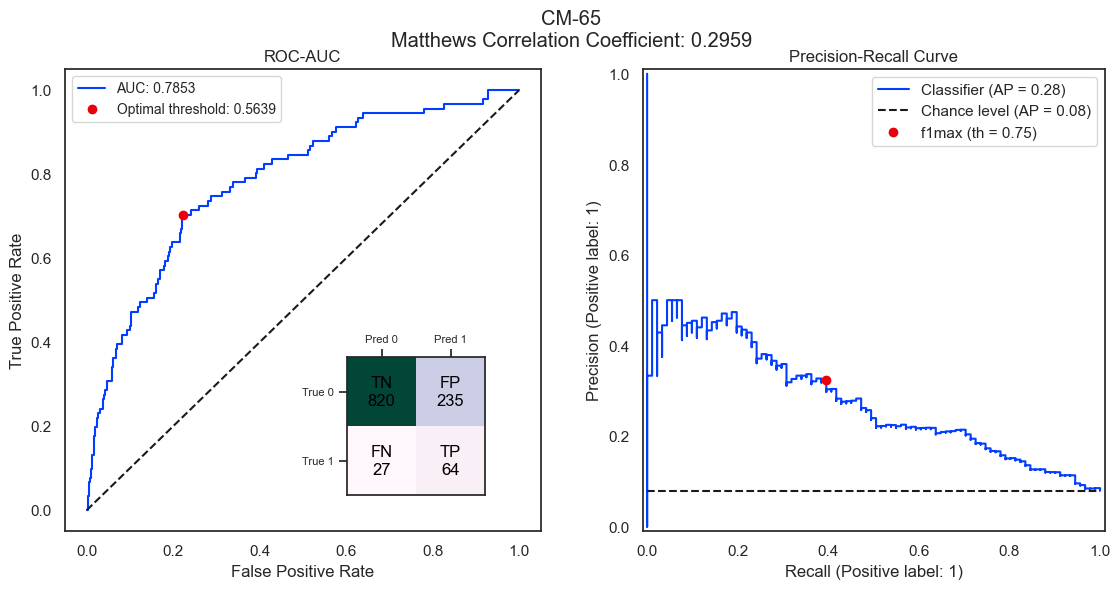

In [81]:
config4 = OptimizationConfig(      
    
    data = Dataset(
        input_column = 'Structure',
        response_column = 'Class',
        training_dataset_file=r'M:\ML_scripts\65_assay\colistin_train.csv',
        test_dataset_file=r'M:\ML_scripts\65_assay\colistin_test.csv',
    ),
    descriptors=[
        ECFP.new(),
        ECFP_counts.new(),
        MACCS_keys.new(),
        PhyschemDescriptors.new(),
        UnscaledPhyschemDescriptors.new(),
        CompositeDescriptor.new(
            descriptors=[
                ECFP_counts.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                MACCS_keys.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        ),
        CompositeDescriptor.new(
            descriptors=[
                ECFP.new(),
                UnscaledPhyschemDescriptors.new(),
            ]
        )
    ],
    algorithms=[
        RandomForestClassifier.new(),
        SVC.new(),
        LogisticRegression.new(),
        KNeighborsClassifier.new(),
    ],
    settings=OptimizationConfig.Settings(
        mode=ModelMode.CLASSIFICATION,
        cross_validation=10,
        cv_split_strategy=Stratified(),
        n_trials=200,
        n_startup_trials=50,
        direction=OptimizationDirection.MAXIMIZATION,
        random_seed=42,
        n_jobs=-1
    ),
)

study4 = optimize(config4, study_name='cm65')                                                                                                   

build_best(buildconfig_best(study4), "./cm65_cv.pkl")                                  

with open("./cm65_cv.pkl", "rb") as f:                                                
    model4 = pickle.load(f)

sns.set_theme(style="white", palette='bright')
fig, axs = plt.subplots(1,2, figsize=(13.5, 6))                                     
x = np.linspace(0,1)

test_data = pd.read_csv(config4.data.test_dataset_file)                         
test_smiles = test_data[config4.data.input_column]                            
y_true = test_data[config4.data.response_column]                                 

y_pred = model4.predict_from_smiles(test_smiles)                                 

plt.subplot(121)
## Plotting the ROC curve

fpr, tpr, thresh = sklearn.metrics.roc_curve(y_true, y_pred)           
auc = np.trapz(tpr, fpr) 
                                          
plt.plot(fpr, tpr)                                               
axs[0].set_title('ROC-AUC')

## Optimal threshold using ROC curve

optimal_idx = np.argmin(np.sqrt(np.square(1-tpr) + np.square(fpr)))
optimal_threshold = thresh[optimal_idx]

x_coord, y_coord = fpr[optimal_idx], tpr[optimal_idx]

plt.plot(x_coord, y_coord,'ro');

plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.legend([f'AUC: {auc:.4}', f"Optimal threshold: {optimal_threshold:.4}"], loc='upper left', fontsize=10);
plt.plot(x,x, 'k--', lw=1.5)

## Binary conversion of predictions

y_pred_bin = [1 if value >= optimal_threshold else 0 for value in y_pred]

mcc = matthews_corrcoef(y_pred_bin, y_true)
plt.suptitle(f"CM-65\nMatthews Correlation Coefficient: {mcc:.4}")           
                         

cm = confusion_matrix(y_true, y_pred_bin)                                 

tn, fp, fn, tp = cm.ravel()
values = np.array([[tn,fp], [fn,tp]])
labels = np.array([['TN','FP'],['FN','TP']])

# Plotting the Precision-Recall curve

pos_label = 1 
name = "CM-1"

precision, recall, thresholds = precision_recall_curve(y_true, y_pred, pos_label=pos_label)    
f1_scores = 2 * recall * precision / (recall + precision)                                       
best_th_ix = np.nanargmax(f1_scores)
best_thresh = thresholds[best_th_ix]

average_precision = average_precision_score(y_true, y_pred, pos_label=pos_label)
display = PrecisionRecallDisplay.from_predictions(y_true=y_true, y_pred=y_pred, pos_label=pos_label, plot_chance_level=True, ax=axs[1])

axs[1].plot(name=name)
axs[1].set_title("Precision-Recall Curve")
axs[1].plot(recall[best_th_ix], precision[best_th_ix], "ro", label=f"f1max (th = {best_thresh:.2f})")
axs[1].legend();

# confusion matrix on inset axes

inset_ax = fig.add_axes([0.27,0.17,0.23,0.23])
inset_ax.matshow(values, cmap=plt.cm.PuBuGn)

inset_ax.set_xticks([0, 1])
inset_ax.set_yticks([0, 1])

inset_ax.xaxis.set_ticks_position('top')
inset_ax.yaxis.set_ticks_position('left')

inset_ax.set_xticklabels(['Pred 0', 'Pred 1'], fontsize=8)
inset_ax.set_yticklabels(['True 0', 'True 1'], fontsize=8)

# Add custom TN, FP, FN, TP labels + counts

for (i, j), val in np.ndenumerate(values):
    text = f"{labels[i, j]}\n{val}"
    inset_ax.text(j, i, text, ha='center', va='center', fontsize=12, color='black')

plt.show()

# Extraction of CV fold metrics

## TM-60

In [ ]:
best_trial = model.metadata['buildconfig']['metadata']['best_trial']
trials_df = study.trials_dataframe()

row = trials_df.loc[best_trial, 'user_attrs_test_scores']
keys = ['roc_auc','mcc','auc_pr_cal']
filtered_dict = {key: row[key] for key in keys if key in row}

new_df = pd.DataFrame(filtered_dict)
new_df['model'] = 'tm60_RF'

cols = ['model'] + [col for col in new_df.columns if col != 'model']
new_df = new_df[cols]

In [55]:
new_df

,model,roc_auc,mcc,auc_pr_cal
0,tm60_RF,0.768505,0.377974,0.246592
1,tm60_RF,0.726415,0.352322,0.323907
2,tm60_RF,0.752903,0.357424,0.273157
3,tm60_RF,0.751814,0.398801,0.215430
4,tm60_RF,0.774311,0.390421,0.451072
5,tm60_RF,0.667997,0.241948,0.207706
6,tm60_RF,0.801887,0.430183,0.413831
7,tm60_RF,0.845065,0.466618,0.578180
8,tm60_RF,0.713716,0.220982,0.361918
9,tm60_RF,0.742380,0.352322,0.260096


In [56]:
trials_df.to_csv('./tm60_trials.csv')
new_df.to_csv('./best_trial_fold_metrics.csv')

## CM-60

In [62]:
best_trial2 = model2.metadata['buildconfig']['metadata']['best_trial']
trials_df2 = study2.trials_dataframe()

row2 = trials_df2.loc[best_trial2, 'user_attrs_test_scores']
filtered_dict2 = {key: row2[key] for key in keys if key in row2}

new_df2 = pd.DataFrame(filtered_dict2)
new_df2['model'] = 'cm60_RF'

cols = ['model'] + [col for col in new_df2.columns if col != 'model']
new_df2 = new_df2[cols]

In [63]:
new_df2

,model,roc_auc,mcc,auc_pr_cal
0,cm60_RF,0.751168,0.393656,0.236324
1,cm60_RF,0.848504,0.471940,0.456552
2,cm60_RF,0.784371,0.439201,0.357391
3,cm60_RF,0.759753,0.418380,0.315511
4,cm60_RF,0.740563,0.348403,0.225430
5,cm60_RF,0.741952,0.359755,0.191112
6,cm60_RF,0.811514,0.461725,0.411334
7,cm60_RF,0.818836,0.485110,0.346564
8,cm60_RF,0.765686,0.417420,0.223447
9,cm60_RF,0.740816,0.329950,0.278426


In [64]:
trials_df2.to_csv('./cm60-trials-data/cm60_trials.csv')
new_df2.to_csv('./cm60-trials-data/best_trial_fold_metrics.csv')

# Combined TM-60 and CM-60 CV metrics

In [71]:
final_df = pd.concat([new_df, new_df2])
final_df['cycle'] = final_df.index
final_df['split'] = 'stratified'

In [73]:
final_df.to_csv('./combined_fold_metrics.csv')

## TM-65

In [78]:
best_trial3 = model3.metadata['buildconfig']['metadata']['best_trial']
trials_df3 = study3.trials_dataframe()

row3 = trials_df3.loc[best_trial3, 'user_attrs_test_scores']
keys = ['roc_auc','mcc','auc_pr_cal']
filtered_dict3 = {key: row3[key] for key in keys if key in row3}

new_df3 = pd.DataFrame(filtered_dict3)
new_df3['model'] = 'tm65_RF'

cols = ['model'] + [col for col in new_df3.columns if col != 'model']
new_df3 = new_df3[cols]

In [79]:
new_df3

,model,roc_auc,mcc,auc_pr_cal
0,tm65_RF,0.729796,0.314800,0.241120
1,tm65_RF,0.689388,0.344124,0.258919
2,tm65_RF,0.701224,0.431398,0.202302
3,tm65_RF,0.717551,0.461880,0.178963
4,tm65_RF,0.716327,0.431398,0.241805
5,tm65_RF,0.666531,0.371429,0.189665
6,tm65_RF,0.661633,0.258839,0.154492
7,tm65_RF,0.631429,0.228665,0.164851
8,tm65_RF,0.747755,0.400163,0.287038
9,tm65_RF,0.728571,0.314286,0.235498


## CM-65

In [82]:
best_trial4 = model4.metadata['buildconfig']['metadata']['best_trial']
trials_df4 = study4.trials_dataframe()

row4 = trials_df4.loc[best_trial4, 'user_attrs_test_scores']
filtered_dict4 = {key: row4[key] for key in keys if key in row4}

new_df4 = pd.DataFrame(filtered_dict4)
new_df4['model'] = 'cm65_RF'

cols = ['model'] + [col for col in new_df4.columns if col != 'model']
new_df4 = new_df4[cols]

In [83]:
new_df4

,model,roc_auc,mcc,auc_pr_cal
0,cm65_RF,0.816179,0.428598,0.397828
1,cm65_RF,0.808034,0.443810,0.324766
2,cm65_RF,0.828582,0.511120,0.362463
3,cm65_RF,0.787486,0.429392,0.403573
4,cm65_RF,0.828767,0.483052,0.629462
5,cm65_RF,0.805442,0.444530,0.386460
6,cm65_RF,0.782858,0.376819,0.320425
7,cm65_RF,0.803591,0.485475,0.338061
8,cm65_RF,0.804887,0.415447,0.513857
9,cm65_RF,0.813773,0.443810,0.489908


In [84]:
trials_df3.to_csv('./tm65-trials-data/tm65_trials.csv')
trials_df4.to_csv('./cm65-trials-data/cm65_trials.csv')

new_df3.to_csv('./tm65-trials-data/best_trial_fold_metrics.csv')
new_df4.to_csv('./cm65-trials-data/best_trial_fold_metrics.csv')